<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38982 entries, 0 to 38981
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sku            38982 non-null  object        
 1   dispense_date  38982 non-null  datetime64[ns]
 2   device_id      38982 non-null  object        
 3   package_qty    38982 non-null  int64         
 4   qty_dispensed  38982 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 1.5+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   device_id        722 non-null    object        
 1   global_order_id  722 non-null    object        
 2   restock_date     722 non-null    datetime64[ns]
 3   currency_code    722 non-null    object        
 4   total            722 non-null    float6

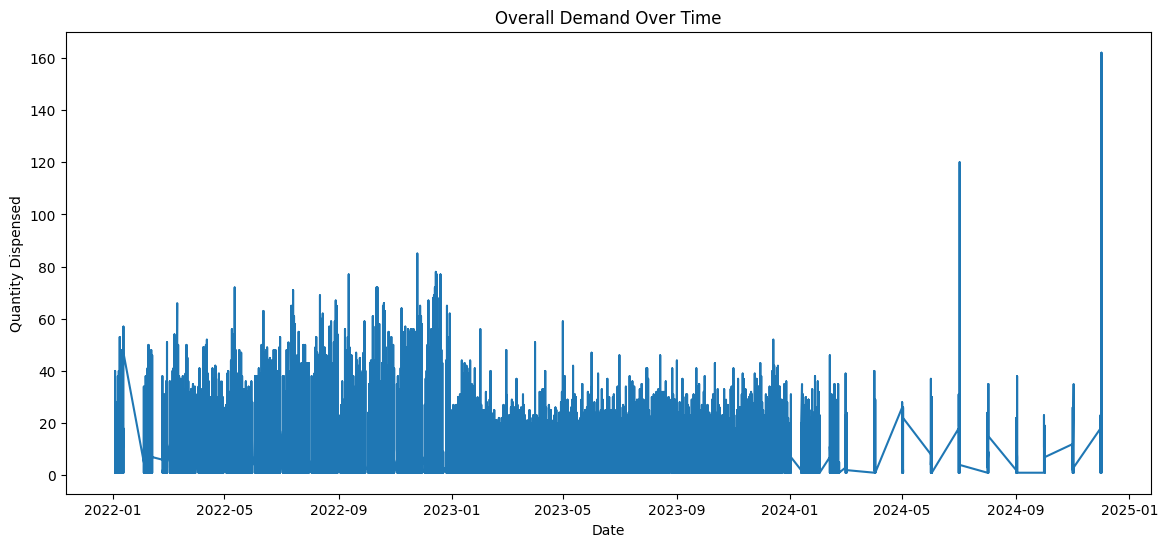

Missing Dates:
DatetimeIndex(['2022-01-13', '2022-01-14', '2022-01-15', '2022-01-16',
               '2022-01-17', '2022-01-18', '2022-01-19', '2022-01-20',
               '2022-01-21', '2022-01-22',
               ...
               '2024-11-21', '2024-11-22', '2024-11-23', '2024-11-24',
               '2024-11-25', '2024-11-26', '2024-11-27', '2024-11-28',
               '2024-11-29', '2024-11-30'],
              dtype='datetime64[ns]', length=337, freq=None)


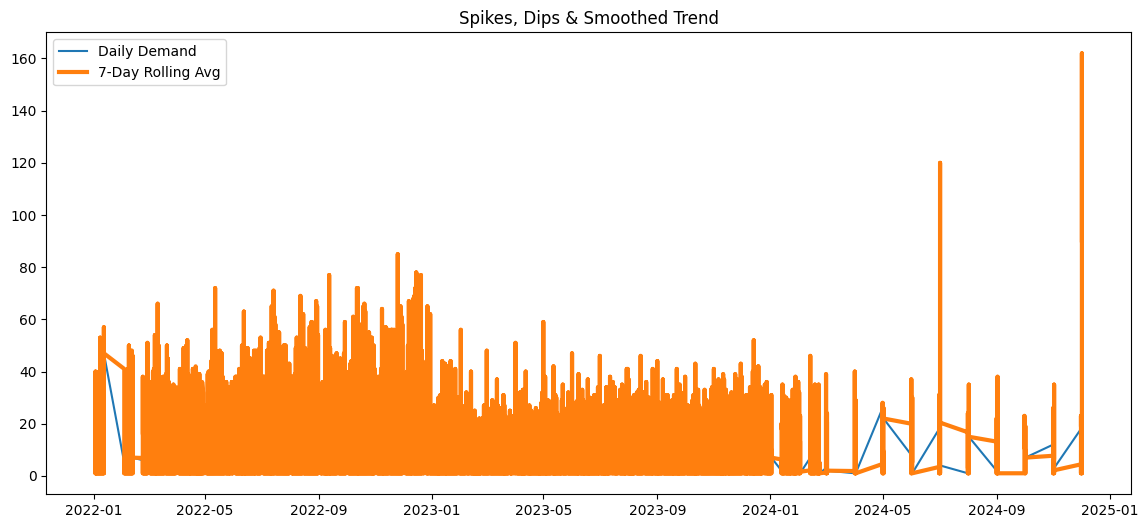

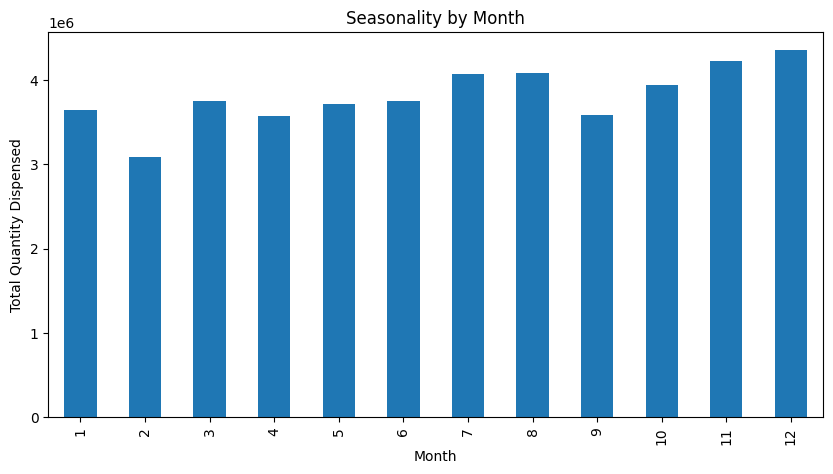

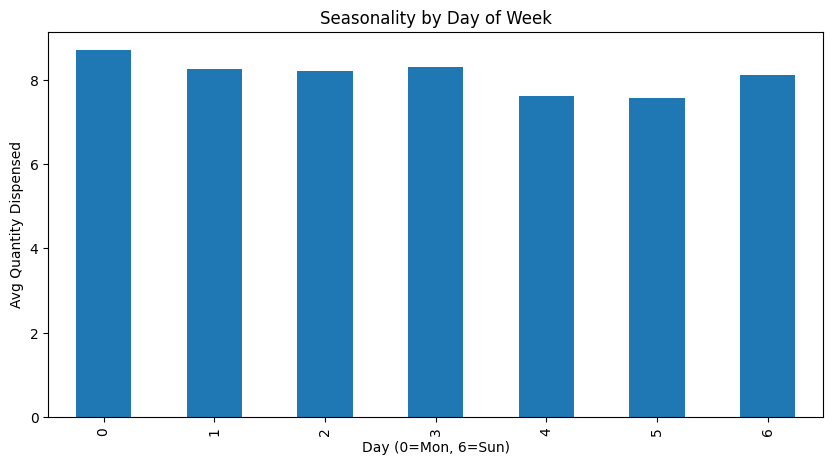

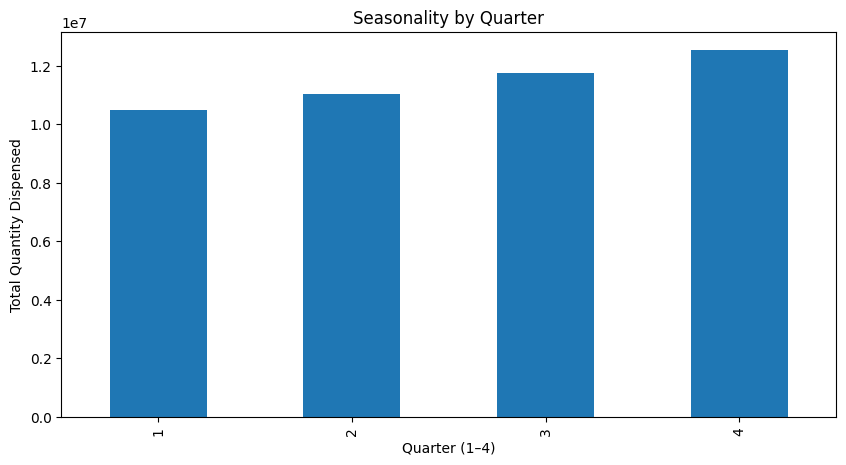

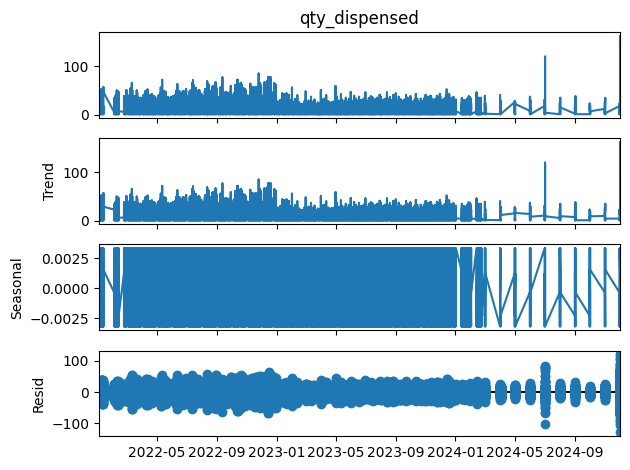

device_id
device_0749c361d8ac7047c2f98fbcb2eadd16    8171532
device_65ae7ea424c57d46ac409256fe359349    9619222
device_6726f2a054f54836aaabe8c7643286bc    9996374
device_af645ebf4c96eb6e430529a2a9913686    8816064
device_c287be7e02167387bf9e7eca061ce5b5    9216134
Name: qty_dispensed, dtype: int64


KeyError: 'dispense_date'

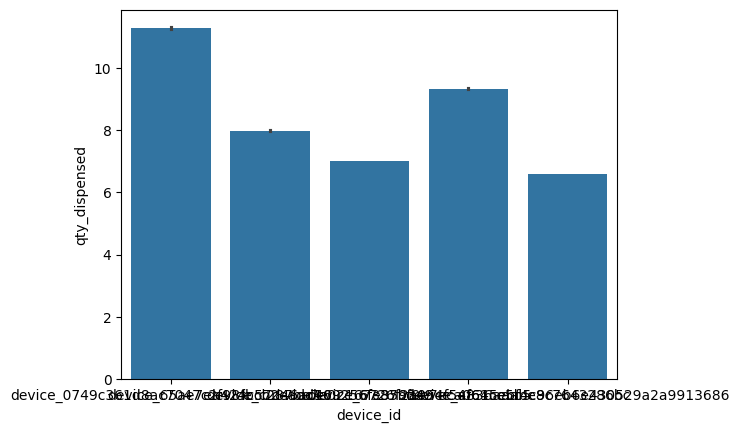

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
inv = pd.read_csv("/Users/kamranabid/Downloads/industrial_forecasting_project/data/Inventory_Turnover.csv")
restock = pd.read_csv("/Users/kamranabid/Downloads/industrial_forecasting_project/data/Restock_data.csv")

# inv.info()
# inv.head()



inv['dispense_date'] = pd.to_datetime(inv['dispense_date'], format='mixed')
restock['restock_date'] = pd.to_datetime(restock['restock_date'], format='mixed')

inv.info()
restock.info()
# restock.head()
# inv.tail()

# inv.isna().sum()
# restock.isna().sum()
# print(inv['sku'].isna().sum())

# Fix missing values:
# inv = inv.fillna(0)
# restock = restock.fillna(0)

# Check Duplicates
# inv.duplicated().sum()

# Remove Duplicates
# inv = inv.drop_duplicates()
# restock = restock.drop_duplicates()

# inv.describe()
# restock.describe()

# Sort Data by Date - Time series MUST be sorted.
inv = inv.sort_values(by="dispense_date")
restock = restock.sort_values(by="restock_date")

# inv.head()
# restock.head()

# inv.groupby('dispense_date')['qty_dispensed'].sum().plot(figsize=(12,5), title="Daily Demand Over Time")

# inv.groupby('sku')['qty_dispensed'].sum().sort_values(ascending=False).head(10)


# inv.groupby("dispense_date")["qty_dispensed"].sum().plot(figsize=(12,5), title="Daily Demand Over Time")
# restock.groupby("restock_date")["total"].sum().plot(figsize=(12,5), title="Restock Demand Over Time")

# inv['sku'].value_counts()
# restock['device_id'].value_counts()

df = inv.merge(restock, on=["device_id"], how="outer")
# print(df)

df['year'] = df['dispense_date'].dt.year
df['month'] = df['dispense_date'].dt.month
df['day_of_week'] = df['dispense_date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'] >= 5

df['lag_1'] = df['qty_dispensed'].shift(1)
df['lag_7'] = df['qty_dispensed'].shift(7)
df['lag_30'] = df['qty_dispensed'].shift(30)

# Year_time = df.groupby(['year'])["qty_dispensed"].plot(figsize=(12,5), title="Yearly Demand Over Time", legend=True )

# df.groupby(df['year'])["qty_dispensed"].sum().plot(legend=True)
# df.groupby(df['month'])["qty_dispensed"].sum().plot(legend=True)

# print(Year_time)
# Monthly_time = df.groupby(['month'])["qty_dispensed"].sum().plot(figsize=(12,5), title="Monthly Demand Over Time")
# print(Monthly_time)
# Weekly_time = df.groupby(['day_of_week'])["qty_dispensed"].sum().plot(figsize=(12,5), title="Weekly Demand Over Time")
# print(Weekly_time)
# Weekend_time = df.groupby(['is_weekend'])["qty_dispensed"].sum().plot(figsize=(12,5), title="Weekend Demand Over Time")
# print(Weekend_time)

# from statsmodels.tsa.seasonal import seasonal_decompose
# seasonal_decompose(df['qty_dispensed'], model='additive', period=7).plot()

# df.groupby("device_id")["qty_dispensed"].sum().sort_values(ascending=False)

# df[['qty_dispensed','total']].corr()

# sns.barplot(data=df, x="total", y="qty_dispensed")
# from statsmodels.tsa.statespace.sarimax import SARIMAX
# model = SARIMAX(df['qty_dispensed'], order=(1,1,1), seasonal_order=(1,1,1,7))
# model_fit = model.fit()
# forecast = model_fit.predict(start, end)

import matplotlib.pyplot as plt

df = df.sort_values("dispense_date")        # Make sure it's in order
df = df.set_index("dispense_date")          # Set Date as index

plt.figure(figsize=(14,6))
plt.plot(df["qty_dispensed"])
plt.title("Overall Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Quantity Dispensed")
plt.show()

# Check for Missing Dates (Missing Periods)
full_range = pd.date_range(df.index.min(), df.index.max(), freq="D")
missing_dates = full_range.difference(df.index)

print("Missing Dates:")
print(missing_dates)

# Rolling Window to Detect Spikes & Dips
df['rolling_mean'] = df['qty_dispensed'].rolling(window=7).mean()

plt.figure(figsize=(14,6))
plt.plot(df['qty_dispensed'], label="Daily Demand")
plt.plot(df['rolling_mean'], label="7-Day Rolling Avg", linewidth=3)
plt.legend()
plt.title("Spikes, Dips & Smoothed Trend")
plt.show()

# Monthly Seasonality
df['month'] = df.index.month

monthly = df.groupby('month')['qty_dispensed'].sum()

monthly.plot(kind="bar", figsize=(10,5))
plt.title("Seasonality by Month")
plt.xlabel("Month")
plt.ylabel("Total Quantity Dispensed")
plt.show()


# Day-of-Week Seasonality
df['day_of_week'] = df.index.dayofweek

dow = df.groupby('day_of_week')['qty_dispensed'].mean()

dow.plot(kind="bar", figsize=(10,5))
plt.title("Seasonality by Day of Week")
plt.xlabel("Day (0=Mon, 6=Sun)")
plt.ylabel("Avg Quantity Dispensed")
plt.show()


# Quarterly Seasonality
df['quarter'] = df.index.quarter

quarterly = df.groupby('quarter')['qty_dispensed'].sum()

quarterly.plot(kind="bar", figsize=(10,5))
plt.title("Seasonality by Quarter")
plt.xlabel("Quarter (1–4)")
plt.ylabel("Total Quantity Dispensed")
plt.show()

# Time-Series Decomposition (Best for Trends + Seasonality)
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['qty_dispensed'], model='additive', period=7)
result.plot()
plt.show()

# Product (SKU) Analysis
df.groupby("sku")["qty_dispensed"].sum().sort_values(ascending=False)

# df[df["sku"] == "sku123"].set_index("dispense_date")["qty_dispensed"].plot()


# Correlation Analysis - Check correlations between: Quantity dispensed, Restock frequency, Restock amount
df[['qty_dispensed','total']].corr()

# Device Utilization - Find busiest/slowest vending machines:

print(df.groupby("device_id")["qty_dispensed"].sum())

# Plot: Identify underused/overused machines.

sns.barplot(data=df, x="device_id", y="qty_dispensed")

# PREP YOUR DATA (REQUIRED BEFORE ARIMA/SARIMA)

# Ensure Date is in datetime format
df['dispense_date'] = pd.to_datetime(df['dispense_date'])

# Sort by date
df = df.sort_values('dispense_date')

# Set index to Date
df = df.set_index('dispense_date')

# Keep only the value we want to forecast
ts = df['qty_dispensed']

# ARIMA MODEL (Beginner Friendly) - ARIMA requires the series to be stationary, so we test that first.
# Check stationarity (ADF Test)

from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(ts.dropna())
print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])
# If p-value < 0.05, your data is stationary → ARIMA OK
# If p-value > 0.05, differencing is required (ARIMA d>0)

# Fit ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

# (p,d,q) = (1,1,1) is a safe starting point
model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

# Forecast with ARIMA - Forecast the next 30 days:
forecast = model_fit.predict(start=len(ts), end=len(ts)+30)
print(forecast)

# SARIMA MODEL (For Seasonal Patterns) - SARIMA adds seasonality terms: SARIMA(p, d, q) x (P, D, Q, S)
# Where S = seasonal period, e.g.: Daily seasonality → 7 Monthly → 12 For industrial vending demand, weekly seasonality is common → S=7.

# Fit SARIMA Model
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Basic model: (1,1,1) + seasonal (1,1,1,7)
model = SARIMAX(ts,
                order=(1,1,1),
                seasonal_order=(1,1,1,7))

model_fit = model.fit()

print(model_fit.summary())

# Forecast Using SARIMA
# Forecast next 30 days:
sarima_forecast = model_fit.predict(start=len(ts), end=len(ts)+30)
print(sarima_forecast)

# PLOT THE FORECASTS
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Historical values
plt.plot(ts, label="Historical Demand")

# SARIMA forecast
plt.plot(sarima_forecast, label="SARIMA Forecast")

plt.title("Demand Forecast (SARIMA)")
plt.xlabel("Date")
plt.ylabel("Quantity Dispensed")
plt.legend()
plt.show()
